# Severity: Gamma-benchmark for kostnad per registrert egen-skade

Notebooken bruker bare utviklingsårene 2022–2023. 2024 leses aldri. Målet er
en kort og etterprøvbar Gamma-benchmark med samme CV-struktur som frekvens.

In [1]:
import re

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from sklearn.metrics import mean_tweedie_deviance

from src_asserts.severity_asserts import (
    assert_severity_fold_contract,
    assert_severity_spec,
)
from src_asserts.common_glm_asserts import assert_valid_folds
from src_asserts.residual_diagnostics_asserts import assert_residual_diagnostics_result
from src_core_glm.glm_core import (
    cross_validate_glm,
    fit_glm,
    glm_spec,
    prepare_design_frame,
)
from src_core_glm.model_data import (
    assert_development_years,
    build_development_frames,
)
from src_core_glm.validation import build_group_folds
from src_core_glm.model_selection import run_backward_ablation, select_candidate_stage
from src_core_glm.residual_diagnostics import (
    build_residual_diagnostic_summary,
    cross_validate_residual_catboost,
    plot_residual_diagnostic_overview,
)
from src_severity import severity_descriptives
from src_severity.severity_data import build_severity_inputs, summarize_severity_selection

SEED = 100
N_FOLDS = 5
GAMMA_FAMILY = sm.families.Gamma(sm.families.links.Log())
GAMMA_POWER = 2
FIT_SETTINGS = {"maxiter": 200, "tol": 1e-8}

## 1. Datagrunnlag

Vi avgrenser og klargjør bare utviklingsdata. Responsen er gjennomsnittlig
kostnad per registrert skade, og `property_claims` er Gamma-modellens
skadeantallsvekt. Dette tilsvarer en arbeidsantakelse om at et poliseår med
flere skader gir mer presis informasjon om underliggende severity.

In [2]:
frames = build_development_frames()
development = frames["development"]
assert_development_years(development)

severity_inputs = build_severity_inputs(development)
model_frame = severity_inputs["model_frame"]
severity_frame = severity_inputs["severity_frame"]

assert len(severity_frame) == 5_698
assert severity_frame["insured_id"].nunique() == 5_323
assert severity_frame["property_claims"].sum() == 9_979

display(summarize_severity_selection(model_frame, severity_frame))

,Poliseår i modellpopulasjonen,Sum eksponering,Sum registrerte skader,Positive skadeår (severity-utvalg),Unike insured_id i severity-utvalget,Sum skader i severity-utvalget,Skadevektet snittseverity (EUR),Utelatte nær-null-poliseår,Registrerte skader i utelatte år
0,55246,37126.013699,9989,5698,5323,9979,872.64457,9,10


## 2. Validering

For hvert poliseår $i$ modellerer vi

$$
\bar X_i \sim \operatorname{Gamma}(\mu_i, \phi/N_i),\qquad
\log\mu_i = \beta_0 + \sum_j\beta_jx_{ij}.
$$

Her er $\bar X_i$ gjennomsnittskostnad og $N_i$ antall registrerte skader.
Gamma-deviance beregnes out-of-fold og vektes med $N_i$. Fem gruppefolder på
`insured_id` hindrer at samme forsikrede finnes i både trening og validering.
Foldene bygges på hele modellpopulasjonen (samme som frekvens og Tweedie).
Modellen fittes og scores på positive skadeår i foldene, men predikerer alle
poliseår i valideringsfolden, slik at frekvens × severity senere kan
beregnes for hele porteføljen.

In [3]:
cv_folds = build_group_folds(
    model_frame,
    group_column="insured_id",
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED,
)
assert_valid_folds(cv_folds, model_frame)  # sanity-sjekk, kan fjernes

## 3. Modellspesifikasjoner

Kjernen er den eksisterende severity-modellen: produkt, år, kommunetype,
aldersspline og log-bilverdi. Kandidatene nedenfor er bare alternative
funksjonsformer eller ett tillegg om gangen. Ingen kandidat får særregler.

In [4]:
BASE_LEVELS = {
    "policy_type": "COMP_E",
    "year": 2022,
    "municipality_type": "I",
    "circulation_area": "U",
    "seat_category": "=5",
    "fuel_type": "D",
    "business_type": "NB",
    "payment_frequency": "A",
}
CORE_PREDICTORS = [
    "policy_type",
    "year",
    "municipality_type",
    "driver_age",
    "log_vehicle_value",
]


def spline(column, df=3):
    """Sentrert naturlig kubisk spline som ett patsy-ledd."""
    return f"cr({column}, df={df}, constraints='center')"


def raw_columns(terms):
    """Hent råkolonnene som imputasjonen trenger fra formelleddene."""
    return [
        re.match(r"cr\((\w+)", term)[1] if term.startswith("cr(") else term
        for term in terms
    ]


def build_severity_specification(name, predictors, spline_terms=()):
    """Bygg én Gamma-spesifikasjon fra råprediktorer og valgte spliner."""
    spline_map = dict(spline_terms)
    terms = [
        spline(column, spline_map[column]) if column in spline_map else column
        for column in predictors
    ]
    return glm_spec(
        name,
        terms,
        "average_severity",
        severity_frame,
        GAMMA_FAMILY,
        "property_claims",
        GAMMA_POWER,
        required_columns=raw_columns(terms),
        base_level_overrides=BASE_LEVELS,
    )


BASE_SPLINES = [("driver_age", 3)]


def evaluate_candidate(specification):
    """Gruppe-CV: fit/score på severity-utvalget, prediksjon for hele valideringsfolden."""
    result = cross_validate_glm(
        specification,
        severity_frame,
        cv_folds,
        prediction_data=model_frame,
        fit_kwargs=FIT_SETTINGS,
    )
    if result["valid"]:  # sanity-sjekk, kan fjernes
        assert_severity_fold_contract(result, model_frame, severity_frame, cv_folds)
    return result

## 4. Sammenligning og valg

En kandidat velges bare dersom den har lavere pooled, skadeantallsvektet
OOF Gamma-deviance enn foreldremodellen, lavere deviance i minst fire av fem
folder og gyldig fit i alle folder. Dette er samme regel for funksjonsform,
tilleggsvariabler og ablasjon; antall parametere gir ingen særregel.

In [5]:
specifications = {
    "kjernevariabler": build_severity_specification(
        "kjernevariabler", CORE_PREDICTORS, BASE_SPLINES
    )
}
assert_severity_spec(specifications["kjernevariabler"])  # sanity-sjekk, kan fjernes
cv_results = {"kjernevariabler": evaluate_candidate(specifications["kjernevariabler"])}


def select_stage(parent_name, candidate_names):
    """Bruk den felles treleddsregelen for dette severity-datasettet."""
    return select_candidate_stage(
        cv_results,
        parent_name,
        candidate_names,
        severity_frame["average_severity"],
        severity_frame["property_claims"],
        power=GAMMA_POWER,
    )

### 4.1 Funksjonsform

Alders- og bilverdieffekten utfordres med de eksisterende funksjonsformene.
Bare den beste kvalifiserte kandidaten går videre.

In [6]:
form_candidates = {
    "alder_lineær": build_severity_specification("alder_lineær", CORE_PREDICTORS, []),
    "alder_spline_df2": build_severity_specification(
        "alder_spline_df2", CORE_PREDICTORS, [("driver_age", 2)]
    ),
    "alder_spline_df4": build_severity_specification(
        "alder_spline_df4", CORE_PREDICTORS, [("driver_age", 4)]
    ),
    "bilverdi_spline": build_severity_specification(
        "bilverdi_spline", CORE_PREDICTORS,
        [("driver_age", 3), ("log_vehicle_value", 3)],
    ),
}
specifications.update(form_candidates)
cv_results.update({
    name: evaluate_candidate(spec)
    for name, spec in form_candidates.items()
})
form_model_name, form_selection = select_stage("kjernevariabler", list(form_candidates))
display(form_selection.round(4))

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,cv_feil
modell,,,,,
alder_lineær,0.7283,True,False,True,
alder_spline_df2,0.7285,True,False,True,
alder_spline_df4,0.7285,True,False,True,
bilverdi_spline,0.7296,False,False,True,


### 4.2 Geografi

Kommunetype kan erstattes av kjøresone eller suppleres med kjøresone. Begge
behandles som vanlige kandidater mot modellen fra forrige trinn.

In [7]:
def spline_terms_from_specification(specification):
    """Les valgte splinegrader fra spesifikasjonen."""
    terms = []
    for term in specification["x"]:
        match = re.match(r"cr\((\w+), df=(\d+)", term)
        if match:
            terms.append((match.group(1), int(match.group(2))))
    return terms


current_predictors = specifications[form_model_name]["required_columns"]
current_splines = spline_terms_from_specification(specifications[form_model_name])
geography_candidates = {
    "kjerne_med_kjøresone": build_severity_specification(
        "kjerne_med_kjøresone",
        ["circulation_area" if column == "municipality_type" else column for column in current_predictors],
        current_splines,
    ),
    "kjerne_med_begge_geografier": build_severity_specification(
        "kjerne_med_begge_geografier", [*current_predictors, "circulation_area"], current_splines
    ),
}
specifications.update(geography_candidates)
cv_results.update({
    name: evaluate_candidate(spec)
    for name, spec in geography_candidates.items()
})
geography_model_name, geography_selection = select_stage(form_model_name, list(geography_candidates))
display(geography_selection.round(4))

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,cv_feil
modell,,,,,
kjerne_med_kjøresone,0.7255,True,True,True,
kjerne_med_begge_geografier,0.7279,True,False,True,


### 4.3 Tilleggsvariabler

Én forhåndsdefinert utvidelse testes om gangen. Ytelse utfordres både lineært
og som spline; de øvrige variablene bruker sin eksisterende definisjon.

In [8]:
current_predictors = specifications[geography_model_name]["required_columns"]
current_splines = spline_terms_from_specification(specifications[geography_model_name])
additional_candidates = {
    "med_ytelse_lineær": build_severity_specification(
        "med_ytelse_lineær", [*current_predictors, "performance_hp_per_tonne"], current_splines
    ),
    "med_ytelse_spline": build_severity_specification(
        "med_ytelse_spline", [*current_predictors, "performance_hp_per_tonne"],
        [*current_splines, ("performance_hp_per_tonne", 3)],
    ),
    "med_seter": build_severity_specification("med_seter", [*current_predictors, "seat_category"], current_splines),
    "med_drivstoff": build_severity_specification("med_drivstoff", [*current_predictors, "fuel_type"], current_splines),
    "med_forretningstype": build_severity_specification("med_forretningstype", [*current_predictors, "business_type"], current_splines),
    "med_betalingsfrekvens": build_severity_specification("med_betalingsfrekvens", [*current_predictors, "payment_frequency"], current_splines),
    "med_bilmerke": build_severity_specification("med_bilmerke", [*current_predictors, "vehicle_brand_pooled"], current_splines),
}
specifications.update(additional_candidates)
cv_results.update({
    name: evaluate_candidate(spec)
    for name, spec in additional_candidates.items()
})
selected_model_name, additional_selection = select_stage(geography_model_name, list(additional_candidates))
display(additional_selection.round(4))

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,cv_feil
modell,,,,,
med_ytelse_lineær,0.7261,False,False,True,
med_ytelse_spline,0.7268,False,False,True,
med_seter,0.7242,True,False,True,
med_drivstoff,0.7269,False,False,True,
med_forretningstype,0.7243,True,True,True,
med_betalingsfrekvens,0.7257,False,False,True,
med_bilmerke,0.7285,False,False,True,


### 4.4 Ablasjon

Vi tester å fjerne én ikke-beskyttet råprediktor om gangen fra modellen som
nå er valgt. En fjerning beholdes bare når den oppfyller den samme
treleddsregelen, og prosessen gjentas til ingen kvalifisert fjerning gjenstår.

In [9]:
def build_ablation_candidate(current_name, column):
    predictors = specifications[current_name]["required_columns"]
    splines = spline_terms_from_specification(specifications[current_name])
    remaining = [item for item in predictors if item != column]
    terms = [item for item in splines if item[0] in remaining]
    name = f"{current_name}_uten_{column}"
    return build_severity_specification(name, remaining, terms)


final_model_name, removed_predictors, ablation_tables = run_backward_ablation(
    selected_model_name,
    specifications,
    cv_results,
    {"policy_type", "year"},
    build_ablation_candidate,
    evaluate_candidate,
    select_stage,
)
for ablation_table in ablation_tables:
    display(ablation_table.round(4))
final_specification = specifications[final_model_name]
print("Valgt severity-modell:", final_model_name)
print("Fjernet i ablasjon:", ", ".join(removed_predictors) or "ingen")

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,cv_feil,fjernet_variabel
modell,,,,,,
med_forretningstype_uten_circulation_area,0.7255,False,False,True,,circulation_area
med_forretningstype_uten_driver_age,0.7233,True,True,True,,driver_age
med_forretningstype_uten_log_vehicle_value,0.7294,False,False,True,,log_vehicle_value
med_forretningstype_uten_business_type,0.7255,False,False,True,,business_type


,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,cv_feil,fjernet_variabel
modell,,,,,,
med_forretningstype_uten_driver_age_uten_circulation_area,0.7247,False,False,True,,circulation_area
med_forretningstype_uten_driver_age_uten_log_vehicle_value,0.7282,False,False,True,,log_vehicle_value
med_forretningstype_uten_driver_age_uten_business_type,0.7244,False,False,True,,business_type


Valgt severity-modell: med_forretningstype_uten_driver_age
Fjernet i ablasjon: driver_age


## 5. Storskader

Figuren viser kostnadskonsentrasjon og fordelingen av gjennomsnittskostnad
per skadeår. Den er diagnostisk: skadeårene er ikke enkeltskader, og verken
terskler eller kapping brukes i kandidatsøket. Som vi ser er ikke storskadeproblematikken særlig fremtredende.

Dette er ikke uforventet, kasko skader har en naturlig øvre grense begrenset av bilverdi. Dette er noe å være særlig oppmerksom på ved modell utvidelse til ulike forsikringskategorier. 

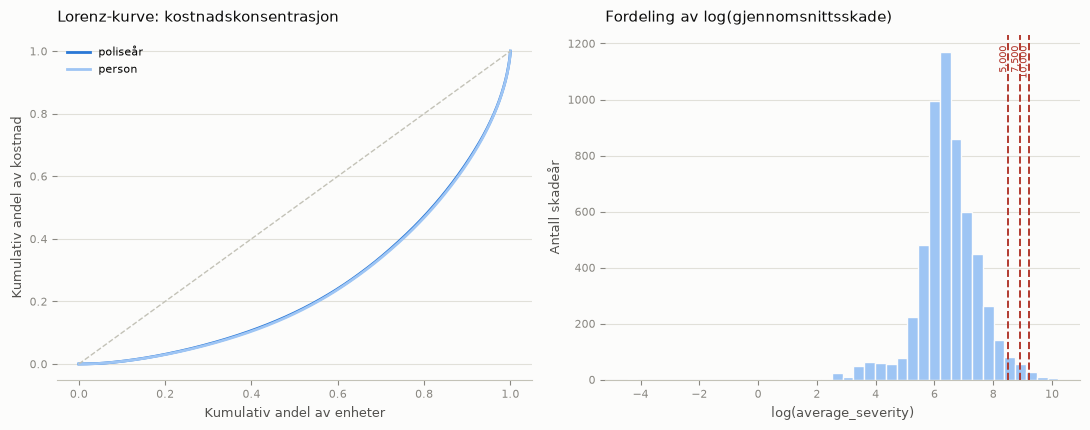

In [10]:
display(severity_descriptives.plot_cost_concentration(severity_frame))

## 6. Koeffisienttabell for valgt modell

Koeffisientene estimeres på hele utviklingsutvalget med cluster-robuste
standardfeil på `insured_id`. De beskriver justerte sammenhenger i disse
utviklingsdataene, ikke kausale effekter.

In [11]:
final_design = prepare_design_frame(severity_frame, severity_frame, final_specification["required_columns"])
final_fit = fit_glm(
    final_specification, final_design, cluster_groups=final_design["insured_id"], fit_kwargs=FIT_SETTINGS
)
confidence = final_fit.conf_int()
coefficient_table = pd.DataFrame({
    "ledd": final_fit.params.index,
    "koeffisient": final_fit.params.to_numpy(),
    "SE_cluster": final_fit.bse.to_numpy(),
    "relativitet": np.exp(final_fit.params.to_numpy()),
    "relativitet_lav": np.exp(confidence[0].to_numpy()),
    "relativitet_høy": np.exp(confidence[1].to_numpy()),
})
display(coefficient_table.round(3))

,ledd,koeffisient,SE_cluster,relativitet,relativitet_lav,relativitet_høy
0,Intercept,4.821,0.377,124.093,59.299,259.682
1,"C(policy_type, Treatment('COMP_E'))[T.COMP_N]",-0.395,0.031,0.674,0.634,0.715
2,"C(year, Treatment(2022))[T.2023]",-0.051,0.036,0.950,0.885,1.020
3,"C(circulation_area, Treatment('U'))[T.R]",0.103,0.033,1.108,1.038,1.183
4,"C(business_type, Treatment('NB'))[T.P]",-0.083,0.033,0.920,0.863,0.982
5,log_vehicle_value,0.205,0.037,1.228,1.143,1.319


## 7. Konkurrerende modeller

Tabellen viser valgt modell og de tre nærmeste gyldige alternativene målt ved
OOF Gamma-deviance. `spesifikasjon` gjør sammenligningen mulig å lese uten å
slå opp modell-ID-en. OOF-resultatene er utviklingsresultater og inkluderer
seleksjonsoptimisme; de er ikke en evaluering på 2024.

In [12]:
def summarize_candidate(name, result):
    """Samle OOF-mål og spesifikasjon for én gyldig severity-kandidat."""
    oof_deviance = mean_tweedie_deviance(
        severity_frame["average_severity"], result["oof"],
        sample_weight=severity_frame["property_claims"], power=GAMMA_POWER,
    )
    return {
        "modell": name,
        "spesifikasjon": specifications[name]["formula"],
        "oof_deviance": oof_deviance,
        "parametere": int(result["scores"]["n_params"].mean()),
    }


candidate_metrics = pd.DataFrame([
    summarize_candidate(name, result)
    for name, result in cv_results.items()
    if result["valid"] and result["oof"].notna().all()
]).set_index("modell")
competitor_names = [final_model_name] + [
    name for name in candidate_metrics.sort_values("oof_deviance").index
    if name != final_model_name
][:3]
decision_table = candidate_metrics.loc[competitor_names]
display(decision_table.round(4))

,spesifikasjon,oof_deviance,parametere
modell,,,
med_forretningstype_uten_driver_age,"average_severity ~ C(policy_type, Treatment('C...",0.7233,6
med_seter,"average_severity ~ C(policy_type, Treatment('C...",0.7242,10
med_forretningstype,"average_severity ~ C(policy_type, Treatment('C...",0.7243,9
med_forretningstype_uten_driver_age_uten_business_type,"average_severity ~ C(policy_type, Treatment('C...",0.7244,5


## 8. CatBoost-diagnostikk av residualstruktur

Vi spør om det finnes struktur i forventet kostnad som den valgte Gamma-GLM-en
ikke fanger. CatBoost er kun en diagnose og velger aldri GLM-variabler.

$$
z_i=\frac{y_i}{\hat\mu_{i,\mathrm{inner\ OOF}}},
\qquad
a_i=w_i\,\hat\mu_{i,\mathrm{inner\ OOF}}^{\,2-p},
\qquad
\hat\mu_i^*=\hat\mu_{i,\mathrm{GLM}}\,\hat h(x_i).
$$

Her er $y_i$ gjennomsnittskostnad, $w_i=N_i$ skadeantall og $p=2$ (Gamma), så
$a_i=w_i$. $z_i$ er observert kostnad relativt til GLM-prediksjonen (rundt 1
hvis GLM-en treffer) og $\hat h(x)$ er CatBoosts korreksjonsfaktor lært med
Poisson-loss. **Indre CV** (fem nye `insured_id`-folder inne i hver ytre
treningsdel) lager $z_i$, så CatBoost aldri trener på prediksjoner fra en GLM
som har sett raden. **Ytre CV** måler gevinsten på forsikrede CatBoost ikke
har sett. Dybde 1 er additiv, dybde 3 kan også fange interaksjoner. Kjøringen
bruker bare de positive severity-radene; skadefrie år konstrueres ikke inn.

In [13]:
diagnostic_features = final_specification["required_columns"]
diagnostic_categorical = tuple(final_specification["base_levels"])

residual_diagnostics = cross_validate_residual_catboost(
    final_specification,
    severity_frame,
    cv_folds,  # bygget på model_frame og skjæres mot severity_frame
    diagnostic_features,
    categorical_columns=diagnostic_categorical,
    blocked_feature_columns=("property_incurred",),  # kostnaden er responsen
    fit_kwargs=FIT_SETTINGS,
    seed=SEED,
)
assert_residual_diagnostics_result(residual_diagnostics, severity_frame, cv_folds)  # kan fjernes

### 8.1 Finnes det residualstruktur?

Tabellen sammenligner GLM-en med en konstant korreksjon (bare nivå) og to
CatBoost-dybder, beregnet på alle OOF-rader med Gamma-deviance. `delta_*` er
reduksjon i deviance (positivt er bedre), `better_than_*_folds` teller ytre
folder med gevinst og `oof_ae` er faktisk delt på predikert kostnad.

In [14]:
display(build_residual_diagnostic_summary(residual_diagnostics).round(4))

,benchmark,pooled_oof_deviance,delta_vs_glm,relative_gain_vs_glm,delta_vs_constant,delta_vs_depth_1,better_than_glm_folds,better_than_constant_folds,better_than_depth_1_folds,oof_ae,valid
0,glm,0.7233,0.0000,0.0000,0.0000,NaN,0,3,NaN,1.0003,True
1,constant,0.7233,-0.0000,-0.0000,0.0000,NaN,2,0,NaN,0.9987,True
2,catboost_depth_1,0.7236,-0.0003,-0.0004,-0.0003,NaN,3,2,NaN,0.9990,True
3,catboost_depth_3,0.7266,-0.0033,-0.0045,-0.0033,-0.003,1,0,0.0,0.9986,True


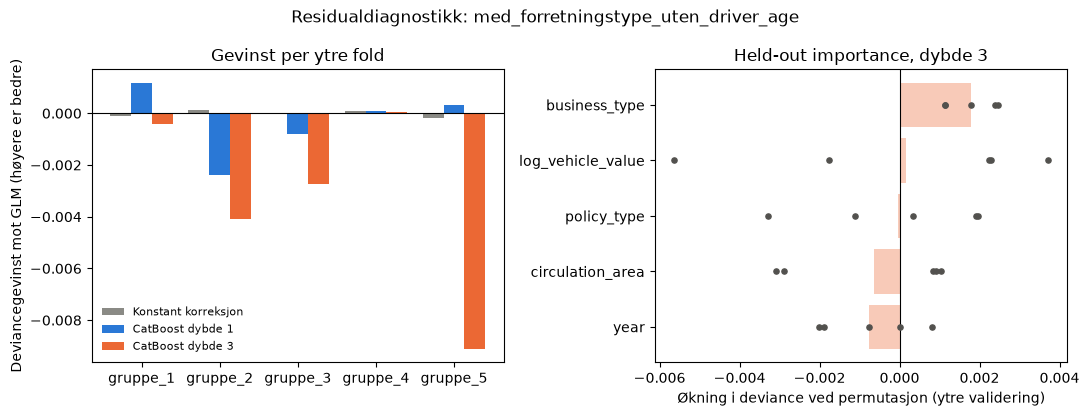

In [15]:
residual_overview_figure = plot_residual_diagnostic_overview(residual_diagnostics)

**Tolkning.** CatBoost forbedrer ikke pooled OOF-deviance mot Gamma-GLM-en:
dybde 1 er omtrent lik og dybde 3 er dårligere, og ingen av dem slår GLM-en
i mer enn tre av fem ytre folder. Konstant korreksjon endrer ingenting, så
kostnadsnivået er godt kalibrert. Det indikerer at en fleksibel modell med
disse variablene ikke finner stabil struktur GLM-en har oversett, i tråd med
at 5 698 skadeår gir lite å lære av. Fravær av gevinst er ikke bevis for
fravær av struktur. Uten stabil gevinst hoppes importance- og SHAP-visningene
over, og importance-panelet i figuren er ikke grunnlag for å peke ut variabler.

**Begrensning.** GLM-en er valgt ved gjentatt bruk av de samme ytre foldene.
Diagnostikken er derfor en utviklingsdiagnose, ikke en uavhengig test og
ikke en evaluering av hele seleksjonsprosedyren.

## 9. Statsmodels-sammendrag

In [16]:
display(final_fit.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:       average_severity   No. Observations:                 5698
Model:                            GLM   Df Residuals:                     5692
Model Family:                   Gamma   Df Model:                            5
Link Function:                    Log   Scale:                          3.1038
Method:                          IRLS   Log-Likelihood:                -46425.
Date:                Sat, 19 Sep 2026   Deviance:                       7171.2
Time:                        14:37:09   Pearson chi2:                 1.77e+04
No. Iterations:                    10   Pseudo R-squ. (CS):            0.02848
Covariance Type:              cluster                                         
=================================================================================================================
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                                         4.8210      0.377     12.796      0.000       4.083       5.559
C(policy_type, Treatment('COMP_E'))[T.COMP_N]    -0.3951      0.031    -12.876      0.000      -0.455      -0.335
C(year, Treatment(2022))[T.2023]                 -0.0512      0.036     -1.420      0.156      -0.122       0.019
C(circulation_area, Treatment('U'))[T.R]          0.1028      0.033      3.077      0.002       0.037       0.168
C(business_type, Treatment('NB'))[T.P]           -0.0829      0.033     -2.520      0.012      -0.147      -0.018
log_vehicle_value                                 0.2052      0.037      5.606      0.000       0.133       0.277
=================================================================================================================
"""